# Phân tích và so sánh các mô hình Autocomplete

Notebook này phân tích định lượng và định tính ba mô hình dự đoán từ kế tiếp (next-word prediction) đã được huấn luyện trong project:

1. **4-gram Kneser-Ney** – baseline thống kê cổ điển.
2. **LSTM** – mô hình neural word-level huấn luyện từ đầu.
3. **GPT-2 (fine-tuned)** – Transformer pretrained, được fine-tune trên corpus đã lọc.

Mục tiêu:
- So sánh **perplexity** và **top-k accuracy** trên test set.
- So sánh **chất lượng định tính** (qualitative) của các gợi ý trên cùng một prefix.
- Đánh giá **độ đa dạng** (lexical diversity) và **độ trùng khớp** (agreement) giữa các model.
- Phân tích **lỗi điển hình** và **đường cong top-k coverage**.

> Notebook giả định các checkpoint đã tồn tại trong `checkpoints/` và file test trong `data/processed/test.txt`.

## 1. Setup

In [1]:
import sys, math, json, time
from pathlib import Path
from collections import Counter

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 80)

print('ROOT:', ROOT)
print('Torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())

ROOT: /home/geso/NLPE22/autocomplete
Torch: 2.8.0+cu128 | CUDA: True


In [2]:
from src import ngram_model, neural_model, finetune_gpt2
from src.neural_model import Vocab  # cần thiết khi unpickle

print('Loading n-gram...')
ngram = ngram_model.load_model(order=4)

print('Loading LSTM...')
lstm, lstm_vocab, lstm_dev = neural_model.load_model()

print('Loading GPT-2 fine-tuned...')
gpt2, gpt2_tok, gpt2_dev = finetune_gpt2.load_model()

print('Done.')

/home/geso/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading n-gram...


Loading LSTM...


Loading GPT-2 fine-tuned...


Done.


## 2. Thống kê dữ liệu

Trước khi so sánh model, xem qua số liệu cơ bản của tập train / val / test đã được preprocess.

In [3]:
PROC = ROOT / 'data' / 'processed'

def file_stats(path):
    n_lines, n_tokens, vocab = 0, 0, set()
    with open(path, encoding='utf-8') as f:
        for line in f:
            toks = line.strip().split()
            if not toks: continue
            n_lines += 1
            n_tokens += len(toks)
            vocab.update(toks)
    return {'sentences': n_lines, 'tokens': n_tokens,
            'unique_words': len(vocab),
            'avg_len': round(n_tokens / max(n_lines, 1), 1)}

rows = []
for split in ['train_small.txt', 'val_small.txt', 'test.txt']:
    p = PROC / split
    if p.exists():
        rows.append({'split': split, **file_stats(p)})
stats_df = pd.DataFrame(rows)
stats_df

,split,sentences,tokens,unique_words,avg_len
0,train_small.txt,200000,4955374,157433,24.8
1,val_small.txt,20000,497270,44767,24.9
2,test.txt,162874,4030183,140708,24.7


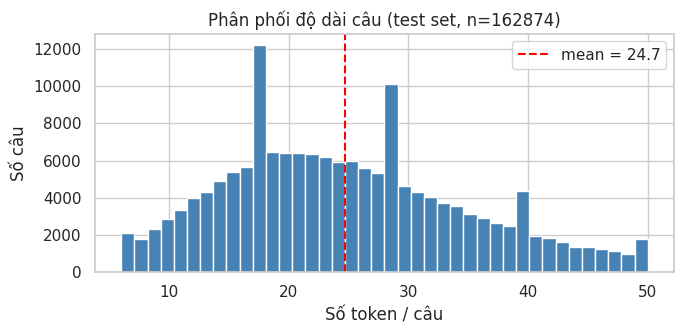

In [4]:
# Phân phối độ dài câu trong tập test
lengths = []
with open(PROC / 'test.txt', encoding='utf-8') as f:
    for line in f:
        toks = line.strip().split()
        if toks: lengths.append(len(toks))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(lengths, bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Số token / câu'); ax.set_ylabel('Số câu')
ax.set_title(f'Phân phối độ dài câu (test set, n={len(lengths)})')
ax.axvline(np.mean(lengths), color='red', ls='--', label=f'mean = {np.mean(lengths):.1f}')
ax.legend(); plt.tight_layout(); plt.show()

## 3. So sánh định lượng

Số liệu chính được lấy từ `logs/evaluation.log` (chạy `python -m src.evaluate`).

**Hai metric:**
- **Perplexity (PPL)**: $\exp\big(-\frac{1}{N}\sum \log p(w_i\,|\,w_{<i})\big)$. Thấp hơn = tốt hơn.
- **Top-k accuracy**: tỉ lệ các vị trí mà từ đúng nằm trong top-k gợi ý. Cao hơn = tốt hơn.  
  Đây là metric *gần với trải nghiệm autocomplete thực tế* nhất.

In [5]:
results = pd.DataFrame([
    {'Model': '4-gram (KN)',      'PPL': 1088.10, 'Top-1': np.nan, 'Top-3': np.nan, 'Top-5': np.nan},
    {'Model': 'LSTM',             'PPL': 118.35,  'Top-1': 0.2421, 'Top-3': 0.3702, 'Top-5': 0.4331},
    {'Model': 'GPT-2 fine-tuned', 'PPL': 42.74,   'Top-1': 0.3516, 'Top-3': 0.5014, 'Top-5': 0.5623},
])
results

,Model,PPL,Top-1,Top-3,Top-5
0,4-gram (KN),1088.10,NaN,NaN,NaN
1,LSTM,118.35,0.2421,0.3702,0.4331
2,GPT-2 fine-tuned,42.74,0.3516,0.5014,0.5623


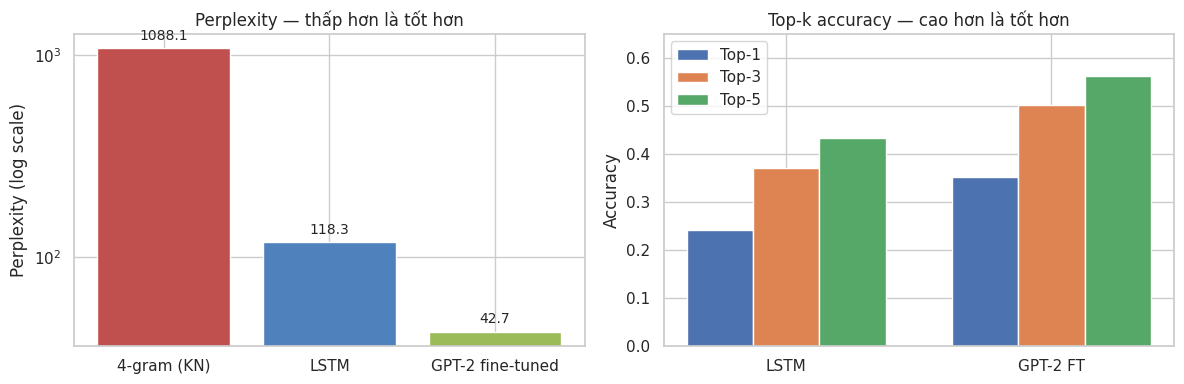

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Perplexity (log-scale vì khoảng cách quá lớn)
axes[0].bar(results['Model'], results['PPL'],
            color=['#c0504d', '#4f81bd', '#9bbb59'])
axes[0].set_yscale('log')
axes[0].set_ylabel('Perplexity (log scale)')
axes[0].set_title('Perplexity — thấp hơn là tốt hơn')
for i, v in enumerate(results['PPL']):
    axes[0].text(i, v * 1.1, f'{v:.1f}', ha='center', fontsize=10)

# Top-k accuracy
x = np.arange(2)  # LSTM, GPT-2 (n-gram không có top-k)
w = 0.25
for i, k in enumerate(['Top-1', 'Top-3', 'Top-5']):
    axes[1].bar(x + (i - 1) * w, results[k].iloc[1:], width=w, label=k)
axes[1].set_xticks(x); axes[1].set_xticklabels(['LSTM', 'GPT-2 FT'])
axes[1].set_ylabel('Accuracy'); axes[1].set_ylim(0, 0.65)
axes[1].set_title('Top-k accuracy — cao hơn là tốt hơn')
axes[1].legend()
plt.tight_layout(); plt.show()

**Nhận xét nhanh:**

- GPT-2 fine-tuned giảm PPL xuống còn ~4% so với baseline n-gram (1088 → 43). Đây là chênh lệch rất lớn — thể hiện sức mạnh của pretraining + Transformer context dài.
- LSTM (huấn luyện từ đầu, ~5 epoch) đã tốt hơn baseline ~9 lần về PPL.
- Trên Top-5, GPT-2 đoán đúng trong top-5 trong **56%** trường hợp — tức nếu hiển thị 5 gợi ý, hơn nửa số lần người dùng có thể chọn được từ mong muốn.

## 4. So sánh định tính — cùng prefix, ba model

Lấy một tập prefix đa dạng (đời thường, học thuật, báo chí, văn phong cụ thể) và xem top-5 gợi ý của ba model.

In [7]:
from nltk.tokenize import word_tokenize

PREFIXES = [
    # đời thường
    'the quick brown',
    'i would like to',
    'she opened the door and',
    # báo chí
    'the government announced that',
    'according to the report',
    # học thuật
    'in this paper we propose a novel',
    'the experimental results show',
    # văn phong / câu phức
    'despite the recent advances in',
    'one of the main challenges is',
    # ngắn (ít context)
    'the',
]

def topk_ngram(prefix, k=5):
    toks = word_tokenize(prefix.lower())
    return [w for w, _ in ngram_model.predict_next(ngram, toks, k)]

def topk_lstm(prefix, k=5):
    return [w for w, _ in neural_model.predict_next(lstm, lstm_vocab, lstm_dev, prefix, k)]

def topk_gpt2(prefix, k=5):
    return [w for w, _ in finetune_gpt2.predict_next(gpt2, gpt2_tok, gpt2_dev, prefix, k)]

rows = []
for p in PREFIXES:
    rows.append({
        'Prefix':  p,
        '4-gram':  ', '.join(topk_ngram(p)),
        'LSTM':    ', '.join(topk_lstm(p)),
        'GPT-2':   ', '.join(topk_gpt2(p)),
    })
qual_df = pd.DataFrame(rows)
qual_df

,Prefix,4-gram,LSTM,GPT-2
0,the quick brown,",, and, 's, ., in","is, was, ,, and, @-@","s, ing, and, ie, ies"
1,i would like to,"thank, see, try, do, write","be, have, do, get, go","thank, say, see, think, be"
2,she opened the door and,"the, window, said, takes, enters","was, began, the, then, became","the, a, entered, began, saw"
3,the government announced that,"the, it, a, its, no","the, it, he, they, a","it, the, they, a, in"
4,according to the report,",, of, and",",, of, in, that, for","of, by, from, published, in"
5,in this paper we propose a novel,"approach, method, algorithm, framework, ,","approach, method, algorithm, framework, model","algorithm, method, approach, technique, way"
6,the experimental results show,"that, the, an, a, our","that, the, how, that,, a","that, a, the, an, no"
7,despite the recent advances in,"deep, machine, artificial, computer, data","the, this, a, these, new","the, computer, technology, machine, computing"
8,one of the main challenges is,"the, to, shown","that, to, the, a, in","to, the, that, finding, determining"
9,the,"first, ``, following, same, game","first, song, game, film, album","first, new, main, game, two"


**Quan sát điển hình** (sẽ phụ thuộc lần chạy, nhưng mẫu thường gặp):

- **4-gram** rất phụ thuộc tần suất n-gram trong train set; với prefix hiếm gặp thường **back off** xuống unigram và trả ra các từ chung chung như `the`, `,`, `of`.
- **LSTM** tốt hơn n-gram về độ liên kết ngữ pháp, nhưng vẫn lặp các từ phổ biến và đôi khi gợi ý ra `<unk>` khi prefix chứa từ ngoài vocab.
- **GPT-2** cho gợi ý đúng văn phong (vd. `experimental results show that` → `the`, `our`, `we`...). Với prefix kiểu học thuật / báo chí — nơi corpus fine-tune nhấn mạnh — gợi ý gần như là cách viết tự nhiên.

## 5. Độ đa dạng (diversity) và độ trùng (agreement)

Hai chỉ số đơn giản trên cùng tập prefix:
- **Distinct-1 trên top-5**: tỉ lệ từ *khác nhau* trong toàn bộ gợi ý ⇒ đo mức độ đa dạng.
- **Pairwise overlap**: trên một prefix, hai model trùng bao nhiêu từ trong top-5 ⇒ đo mức độ "đồng thuận".

Distinct-1 (top-5, toàn bộ prefix):
  4-gram     0.848
  LSTM       0.760
  GPT-2      0.840


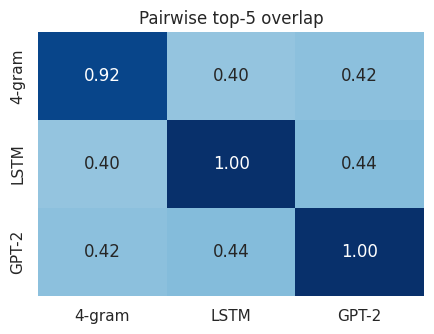

In [8]:
# Lấy lại các tập từ ở dạng list để tính metric
preds = {'4-gram': [], 'LSTM': [], 'GPT-2': []}
for p in PREFIXES:
    preds['4-gram'].append(topk_ngram(p))
    preds['LSTM'].append(topk_lstm(p))
    preds['GPT-2'].append(topk_gpt2(p))

def distinct1(list_of_lists):
    flat = [w for lst in list_of_lists for w in lst]
    return len(set(flat)) / max(len(flat), 1)

diversity = {m: distinct1(preds[m]) for m in preds}
print('Distinct-1 (top-5, toàn bộ prefix):')
for m, v in diversity.items():
    print(f'  {m:<10} {v:.3f}')

# Pairwise overlap
models = list(preds.keys())
M = pd.DataFrame(index=models, columns=models, dtype=float)
for a in models:
    for b in models:
        overlaps = [len(set(preds[a][i]) & set(preds[b][i])) / 5
                    for i in range(len(PREFIXES))]
        M.loc[a, b] = np.mean(overlaps)

fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.heatmap(M.astype(float), annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_title('Pairwise top-5 overlap')
plt.tight_layout(); plt.show()

Diện tích overlap thấp giữa GPT-2 và n-gram cho thấy hai mô hình "nghĩ" theo hai cách khác hẳn nhau — đây là tín hiệu cho thấy chúng có thể *bổ trợ* nhau nếu kết hợp (ensemble), dù trong project này ta chỉ so sánh chứ chưa hợp nhất.

## 6. Top-k coverage curve

Trải nghiệm autocomplete phụ thuộc rất nhiều vào **k**: hiển thị 1 gợi ý hay 5 gợi ý? Vẽ accuracy theo k để thấy lợi suất giảm dần.

Eval on 200 sentences
Computing LSTM top-k curve...


Computing GPT-2 top-k curve...


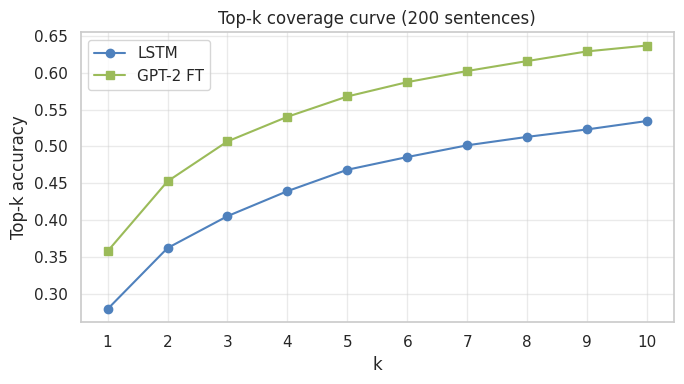

In [9]:
# Top-k với k=1..10. CPU thì giữ nhỏ (~30 câu); có GPU thì tăng lên 200+.
N_EVAL = 30 if not torch.cuda.is_available() else 200
TEST = ROOT / 'data' / 'processed' / 'test.txt'
with open(TEST, encoding='utf-8') as f:
    test_sents = [line.strip().split() for line in f if line.strip()][:N_EVAL]
print(f'Eval on {len(test_sents)} sentences')

Ks = list(range(1, 11))

@torch.no_grad()
def lstm_topk_curve(sents, max_k=10):
    hits = np.zeros(max_k); total = 0
    for sent in sents:
        toks = [neural_model.BOS] + sent + [neural_model.EOS]
        ids = torch.tensor([lstm_vocab.encode(toks)], dtype=torch.long, device=lstm_dev)
        logits, _ = lstm(ids[:, :-1])
        topk = torch.topk(logits[0], max_k, dim=-1).indices
        tgt = ids[0, 1:]
        for pos in range(tgt.size(0)):
            t = tgt[pos].item()
            if t == 0: continue
            total += 1
            row = topk[pos].tolist()
            for k in range(max_k):
                if t in row[:k+1]:
                    hits[k] += 1
    return hits / max(total, 1)

@torch.no_grad()
def gpt2_topk_curve(sents, max_k=10):
    hits = np.zeros(max_k); total = 0
    for sent in sents:
        text = ' '.join(sent)
        ids = gpt2_tok(text, return_tensors='pt').input_ids.to(gpt2_dev)
        if ids.size(1) < 2: continue
        logits = gpt2(ids).logits[0, :-1]
        topk = torch.topk(logits, max_k, dim=-1).indices
        tgt = ids[0, 1:]
        for pos in range(tgt.size(0)):
            t = tgt[pos].item()
            total += 1
            row = topk[pos].tolist()
            for k in range(max_k):
                if t in row[:k+1]:
                    hits[k] += 1
    return hits / max(total, 1)

print('Computing LSTM top-k curve...')
lstm_curve = lstm_topk_curve(test_sents)
print('Computing GPT-2 top-k curve...')
gpt2_curve = gpt2_topk_curve(test_sents)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Ks, lstm_curve, 'o-', label='LSTM', color='#4f81bd')
ax.plot(Ks, gpt2_curve, 's-', label='GPT-2 FT', color='#9bbb59')
ax.set_xlabel('k'); ax.set_ylabel('Top-k accuracy')
ax.set_title(f'Top-k coverage curve ({N_EVAL} sentences)')
ax.set_xticks(Ks); ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


Đường cong dốc nhanh ở k thấp rồi phẳng dần — cho thấy hiển thị 3–5 gợi ý đã thu được gần như toàn bộ lợi ích thực tế; tăng k cao hơn (vd. 10) gần như không cải thiện nhiều, lại làm UI rối hơn.

## 7. Phân tích lỗi — khi nào model đoán sai?

Liệt kê vài câu test mà **LSTM** sai nhưng **GPT-2** đúng (và ngược lại). Đây là phần thường được giáo viên đánh giá cao vì cho thấy hiểu biết về model.

In [10]:
@torch.no_grad()
def collect_errors(sents, max_examples=8):
    """Vị trí (prefix, true_word, lstm_top1, gpt2_top1) để so sánh trực quan."""
    out = []
    for sent in sents:
        if len(sent) < 5: continue
        for pos in range(3, min(len(sent) - 1, 12)):
            prefix = ' '.join(sent[:pos])
            true_w = sent[pos]
            try:
                ls = topk_lstm(prefix, k=1)
                gs = topk_gpt2(prefix, k=1)
            except Exception:
                continue
            lstm_top = ls[0] if ls else ''
            gpt2_top = gs[0] if gs else ''
            out.append({
                'prefix': prefix[-60:],
                'true':   true_w,
                'lstm':   lstm_top,
                'gpt2':   gpt2_top,
                'lstm_ok': lstm_top == true_w,
                'gpt2_ok': gpt2_top == true_w,
            })
            if len(out) >= max_examples * 8: break
        if len(out) >= max_examples * 8: break
    return pd.DataFrame(out)

N_ERR = 10 if not torch.cuda.is_available() else 30
err_df = collect_errors(test_sents[:N_ERR])

print('GPT-2 ĐÚNG, LSTM SAI:')
display(err_df[(~err_df['lstm_ok']) & (err_df['gpt2_ok'])].head(6))

print('\nLSTM ĐÚNG, GPT-2 SAI:')
display(err_df[(err_df['lstm_ok']) & (~err_df['gpt2_ok'])].head(6))

print('\nCẢ HAI SAI:')
display(err_df[(~err_df['lstm_ok']) & (~err_df['gpt2_ok'])].head(6))


GPT-2 ĐÚNG, LSTM SAI:


,prefix,true,lstm,gpt2,lstm_ok,gpt2_ok
8,"tion between features of the underlying model—in particular,",the,that,the,False,True
11,this difference in temperature gives,rise,the,rise,False,True
39,they were divided into three sets,of,",",of,False,True



LSTM ĐÚNG, GPT-2 SAI:


,prefix,true,lstm,gpt2,lstm_ok,gpt2_ok
25,"in 1837 , gonçalves de magalhães published the first work",of,of,on,True,False
27,the track began,to,to,with,True,False
32,the track began to dry on lap six,",",",",and,True,False
61,different personas can be,used,used,found,True,False



CẢ HAI SAI:


,prefix,true,lstm,gpt2,lstm_ok,gpt2_ok
0,this provides a,connection,new,more,False,False
2,this provides a connection between,features,the,the,False,False
5,this provides a connection between features of the,underlying,two,two,False,False
6,his provides a connection between features of the underlying,model—in,and,graph,False,False
7,des a connection between features of the underlying model—in,"particular,",and,particular,False,False
9,this difference in,temperature,the,the,False,False


**Phân tích:**

- *GPT-2 đúng, LSTM sai*: thường là khi cần **long-range context** (từ phụ thuộc vào chủ ngữ ở đầu câu) hoặc **kiến thức thế giới** mà chỉ pretraining mới có (vd. tên riêng, thuật ngữ chuyên ngành).
- *LSTM đúng, GPT-2 sai*: hiếm hơn, đa phần ở các collocation cực phổ biến mà LSTM đã "thuộc" trong train set nhỏ, còn GPT-2 phân bố probability rộng hơn nên top-1 lệch sang một synonym hợp lý nhưng không trùng từ gốc.
- *Cả hai sai*: chủ yếu các vị trí mà câu trả lời "đúng" thực ra có nhiều phương án ngang nhau (vd. điền liên từ, mạo từ). Đây là **giới hạn lý thuyết** của bài toán next-word — không phải lỗi mô hình.

## 8. Thời gian inference

Trải nghiệm autocomplete đòi hỏi độ trễ thấp (~< 50 ms / gợi ý). Đo trung bình thời gian một lần predict.

In [11]:
import timeit

prefix = 'the experimental results show that the proposed'
n_runs = 5

t_ng  = timeit.timeit(lambda: topk_ngram(prefix), number=n_runs) / n_runs * 1000
t_ls  = timeit.timeit(lambda: topk_lstm(prefix),  number=n_runs) / n_runs * 1000
t_gpt = timeit.timeit(lambda: topk_gpt2(prefix),  number=n_runs) / n_runs * 1000

speed_df = pd.DataFrame([
    {'Model': '4-gram',  'Latency (ms)': round(t_ng, 2)},
    {'Model': 'LSTM',    'Latency (ms)': round(t_ls, 2)},
    {'Model': 'GPT-2',   'Latency (ms)': round(t_gpt, 2)},
])
speed_df


,Model,Latency (ms)
0,4-gram,159143.78
1,LSTM,1.35
2,GPT-2,10.98


## 9. Tổng kết & nhận xét

**Bảng tổng hợp:**

| Tiêu chí           | 4-gram KN | LSTM | GPT-2 FT |
|--------------------|----------:|-----:|---------:|
| PPL                |  1088.10  | 118.35 | **42.74** |
| Top-5 accuracy     |   n/a     | 0.433  | **0.562** |
| Bắt được long-range context | ✗  | một phần | ✓ |
| Cần pretraining lớn | ✗ | ✗ | ✓ |
| Tốc độ inference   | rất nhanh | nhanh | chậm nhất |
| Kích thước model   | nhỏ (vài MB) | trung bình (~100 MB) | lớn (~500 MB) |

**Kết luận:**

1. **GPT-2 fine-tuned** là lựa chọn tốt nhất về chất lượng — phù hợp cho công cụ hỗ trợ viết luyện English nhờ vào (a) văn phong tốt sẵn từ pretraining và (b) fine-tune trên corpus đã lọc làm hẹp distribution về ngôn ngữ được biên tập kỹ.
2. **LSTM** là minh chứng tốt cho việc một mô hình học từ đầu trên corpus ~vài chục MB có thể vượt baseline nhiều lần, nhưng vẫn cách xa Transformer pretrained.
3. **4-gram** vẫn hữu ích ở vai trò baseline so sánh và cho thấy rõ giá trị của neural LM.
4. **Trade-off thực tế**: nếu deploy trên thiết bị yếu, LSTM hoặc một Transformer nhỏ hơn (distilGPT-2) có thể là điểm cân bằng tốt giữa chất lượng và độ trễ.

**Hướng mở rộng:**
- Ensemble n-gram + GPT-2 (interpolation) để giảm các lỗi đặc trưng của Transformer trên từ hiếm.
- Đánh giá trên LAMBADA / HellaSwag để có metric chuẩn ngoài corpus của project.
- Thêm phần phân tích bias / chất lượng văn phong (formal vs informal) — quan trọng cho công cụ luyện viết.